# 这个格子我们的目标是：首先解决加载模型的问题。

In [13]:
import os
import torch
import matplotlib.pyplot as plt
# 加载网格的工具函数
from pytorch3d.io import load_objs_as_meshes, load_obj
# 用于渲染的数据结构和函数
from pytorch3d.structures import Meshes 
from pytorch3d.vis.plotly_vis import AxisArgs, plot_batch_individually, plot_scene
from pytorch3d.vis.texture_vis import texturesuv_image_matplotlib
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras, 
    PointLights, 
    DirectionalLights, 
    Materials, 
    RasterizationSettings, 
    MeshRenderer, 
    MeshRasterizer,  
    SoftPhongShader,
    TexturesUV,
    TexturesVertex,
    PerspectiveCameras
)

In [14]:
# 设置
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.cuda.set_device(device)
else:
    device = torch.device("cpu")

# 设置路径
DATA_DIR = "./data"
obj_filename = os.path.join(DATA_DIR, "cow_mesh/cow.obj")

# 加载 obj 文件
mesh = load_objs_as_meshes([obj_filename], device=device)

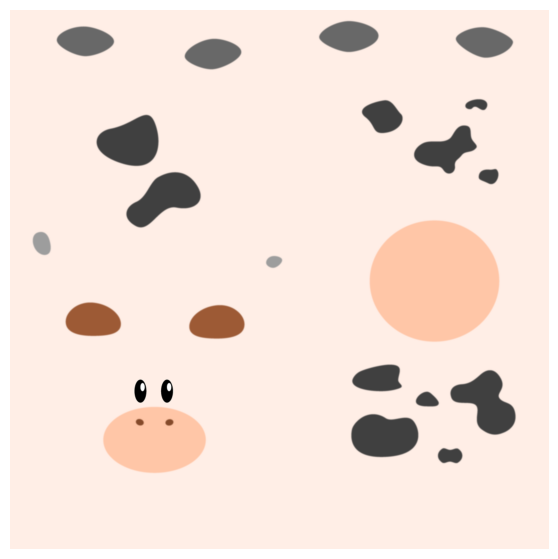

In [15]:
# 贴图可视化
plt.figure(figsize=(7,7))
texture_image=mesh.textures.maps_padded()
plt.imshow(texture_image.squeeze().cpu().numpy())
plt.axis("off");

In [16]:
# R, T = look_at_view_transform(2.7, 0, 180) 
# cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

In [17]:
# # 假设 drone_pos 是无人机位置，target_pos 是它看向的点
# R, T = look_at_view_transform(
#     eye=drone_pos, 
#     at=target_pos, 
#     up=torch.tensor([[0, 0, 1]], device=device) # 假设 Z 轴向上
# )
# # 创建一个批次的相机（例如模拟多架无人机或同一架无人机的连续帧）
# cameras = FoVPerspectiveCameras(
#     fov=90.0,        # 90度视场角
#     znear=0.1,       # 最近可视距离
#     zfar=1000.0,     # 最远可视距离
#     device=device,
#     R=R_tensor,      # 无人机的旋转矩阵
#     T=T_tensor       # 无人机的平移向量
# )

In [18]:
# 定义图像大小 (Height, Width)
H, W = 480, 640
image_size = torch.tensor([[H, W]], device=device)

# 焦距 (fx, fy)
focal_length = torch.tensor([[500.0, 500.0]], device=device)

# 主点 (cx, cy) - 通常在图像中心
principal_point = torch.tensor([[W/2, H/2]], device=device)

# 定义相机外参 (Extrinsics) - R 和 T
# 使用 look_at_view_transform 计算 R 和 T，确保相机能看到物体
# 距离 2.7，方位角 180 度
R, T = look_at_view_transform(dist=2.7, elev=0, azim=180, device=device)

# 初始化相机
# 关键点：设置 in_ndc=False，告诉 PyTorch3D 输入的焦距和主点是像素单位
cameras = PerspectiveCameras(
    focal_length=focal_length,
    principal_point=principal_point,
    image_size=image_size,
    in_ndc=False,  # <--- 关键！表示使用屏幕坐标系（像素）
    R=R,
    T=T,
    device=device
)

# --- 验证测试 ---

In [19]:
# 设置光栅化参数
raster_settings = RasterizationSettings(
    image_size=(H, W), # 输出图像大小，必须与相机定义的图像大小一致
    blur_radius=0.0, # 模糊半径
    faces_per_pixel=1, # 每个像素考虑的面数
    perspective_correct=True # 开启透视校正深度插值，这对获取准确的深度图很重要
)

In [20]:
# 定义一个支持深度输出的自定义渲染器类
class MeshRendererWithDepth(torch.nn.Module):
    def __init__(self, rasterizer, shader):
        super().__init__()
        self.rasterizer = rasterizer
        self.shader = shader

    def forward(self, meshes_world, **kwargs):
        fragments = self.rasterizer(meshes_world, **kwargs)
        images = self.shader(fragments, meshes_world, **kwargs)
        return images, fragments.zbuf

# 设置一个点光源
lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])

# 使用自定义的 MeshRendererWithDepth
renderer = MeshRendererWithDepth(
    rasterizer=MeshRasterizer(
        cameras=cameras, 
        raster_settings=raster_settings
    ),
    shader=SoftPhongShader(
        device=device, 
        cameras=cameras,
        lights=lights
    )
)

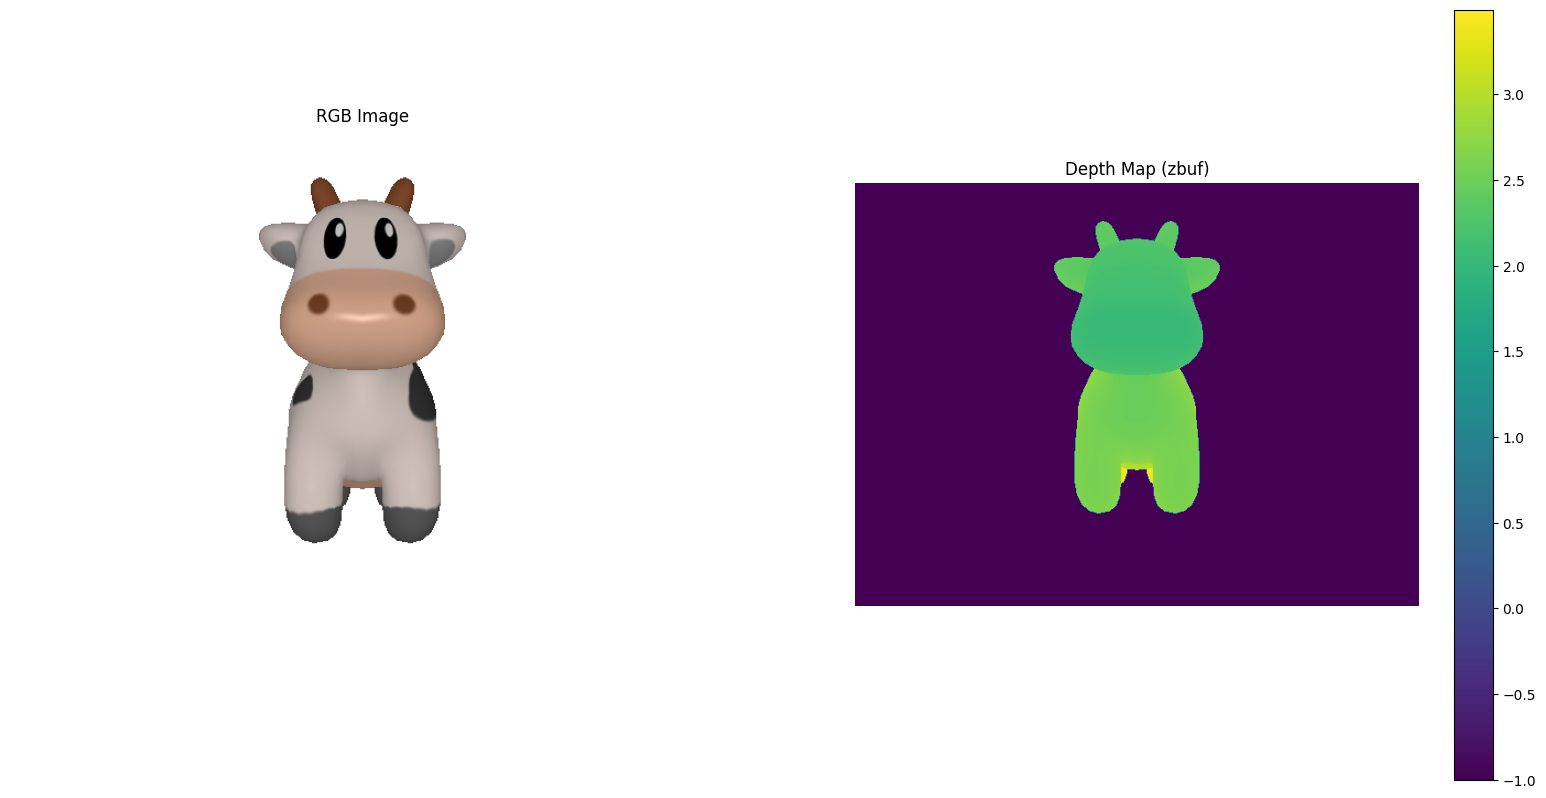

In [21]:
images, depth_map = renderer(mesh)

plt.figure(figsize=(20, 10))

# 显示 RGB 图像
plt.subplot(1, 2, 1)
plt.imshow(images[0, ..., :3].cpu().numpy())
plt.title("RGB Image")
plt.axis("off")

# 显示深度图
# depth_map 的形状是 (N, H, W, K)，这里 K=1
# 注意：背景处的深度通常为 -1，可视化时可能需要处理
depth_image = depth_map[0, ..., 0].cpu().numpy() 
plt.subplot(1, 2, 2)
plt.imshow(depth_image, cmap="viridis") # 使用 viridis 颜色映射更能看清深度变化
plt.title("Depth Map (zbuf)")
plt.axis("off")
plt.colorbar() # 添加颜色条以便观察数值

plt.show()

In [22]:
# 设置参数
max_dist = 0.0  # 最大探测距离，单位与深度图一致
min_dist = 0.2   # 最小探测距离

# 处理背景
depth_image[depth_image == -1] = float('nan')  # 将背景深度设为 NaN 以便忽略
# 模拟最大探测距离
depth_image[depth_image > max_dist] = float('nan')
# 模拟最小探测距离
depth_image[(depth_image < min_dist) & (depth_image > 0)] = float('nan')


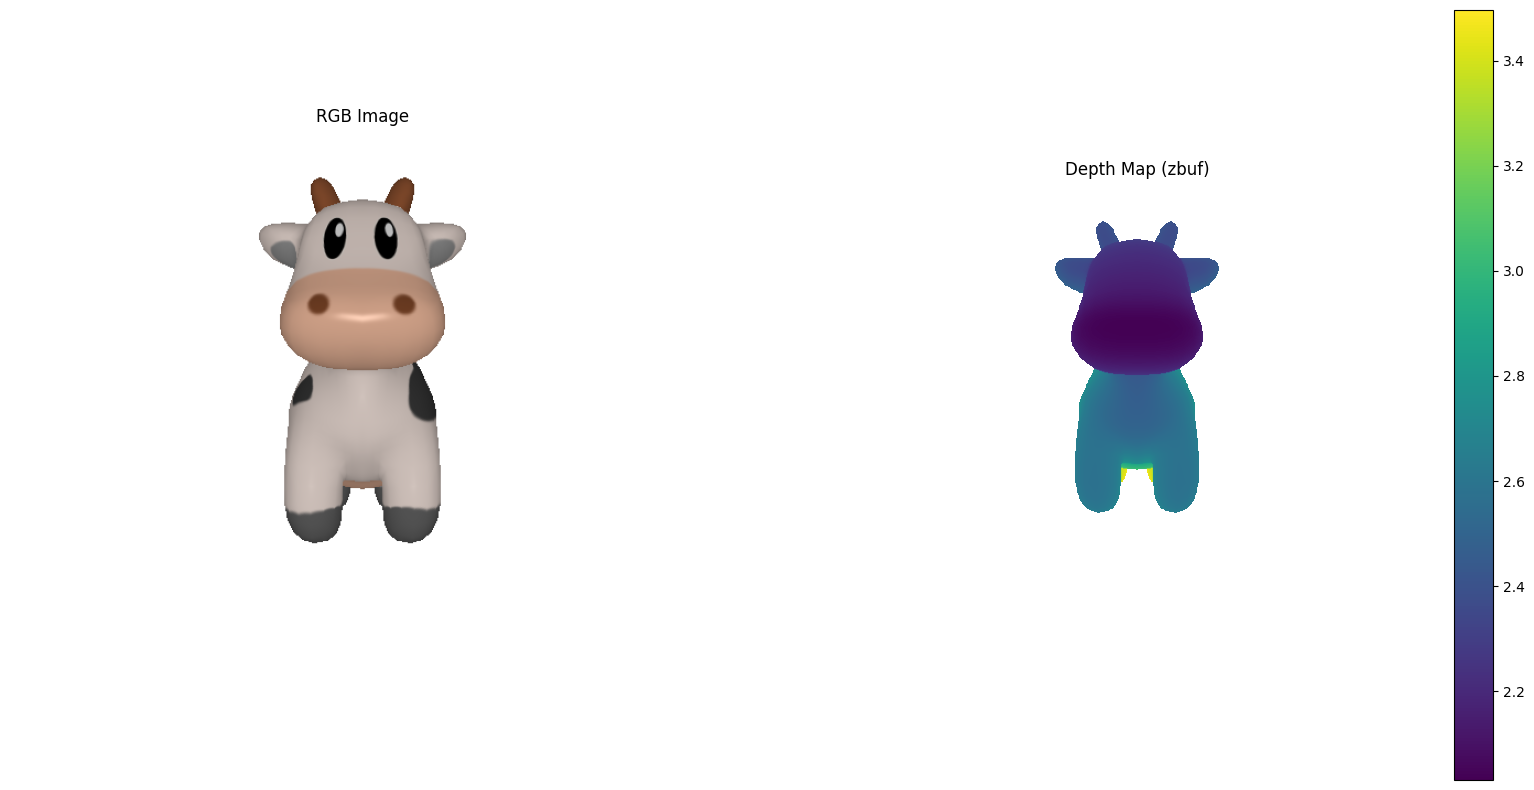

In [23]:
plt.figure(figsize=(20, 10))

# 显示 RGB 图像
plt.subplot(1, 2, 1)
plt.imshow(images[0, ..., :3].cpu().numpy())
plt.title("RGB Image")
plt.axis("off")

# 显示深度图
# depth_map 的形状是 (N, H, W, K)，这里 K=1
# 注意：背景处的深度通常为 -1，可视化时可能需要处理
depth_image = depth_map[0, ..., 0].cpu().numpy() 

# 设置参数
max_dist = 10.0  # 最大探测距离，单位与深度图一致
min_dist = 0.2   # 最小探测距离

# 处理背景
depth_image[depth_image == -1] = float('nan')  # 将背景深度设为 NaN 以便忽略
# 模拟最大探测距离
depth_image[depth_image > max_dist] = float('nan')
# 模拟最小探测距离
depth_image[(depth_image < min_dist) & (depth_image > 0)] = float('nan')


plt.subplot(1, 2, 2)
plt.imshow(depth_image, cmap="viridis") # 使用 viridis 颜色映射更能看清深度变化
plt.title("Depth Map (zbuf)")
plt.axis("off")
plt.colorbar() # 添加颜色条以便观察数值


检测到模型没有纹理，正在自动生成默认白色顶点纹理...


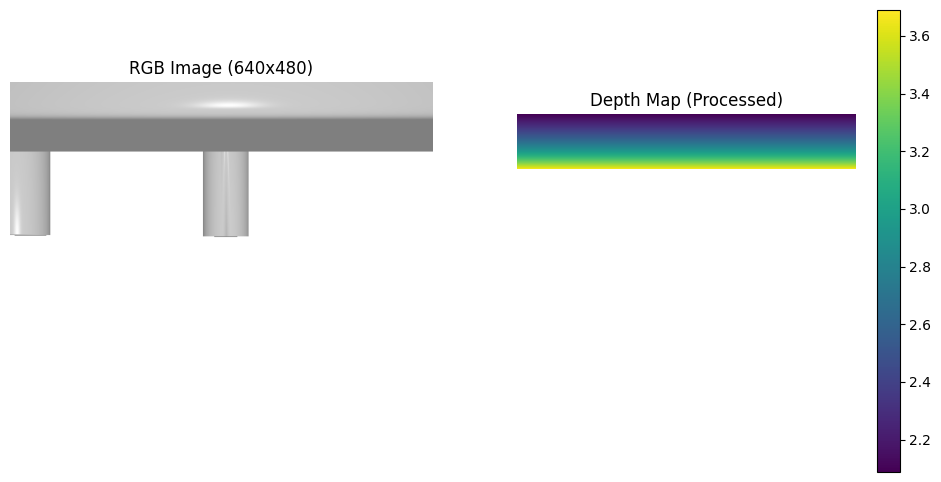

In [24]:
import os
import torch
import matplotlib.pyplot as plt
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer import (
    look_at_view_transform,
    PointLights,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    PerspectiveCameras,
    TexturesVertex # 引入 TexturesVertex 用于创建默认纹理
)

# --- 1. 环境与数据准备 ---
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.cuda.set_device(device)
else:
    device = torch.device("cpu")

DATA_DIR = "./data"
# obj_filename = os.path.join(DATA_DIR, "cow_mesh/cow.obj")
obj_filename = os.path.join(DATA_DIR, "sample/sample.obj") 

# 加载 obj 文件
mesh = load_objs_as_meshes([obj_filename], device=device)

# 关键修复：检查模型是否有纹理，如果没有，手动创建一个纯白色的顶点纹理
# PyTorch3D 的 Shader (无论是 Soft 还是 Hard) 都需要模型有纹理数据才能工作，否则会报错 "Meshes does not have textures"
if mesh.textures is None:
    print("检测到模型没有纹理，正在自动生成默认白色顶点纹理...")
    # 获取第一个网格的顶点 (假设 batch size = 1)
    verts = mesh.verts_list()[0]
    # 创建全白的颜色 (1, V, 3)
    verts_rgb = torch.ones_like(verts)[None] 
    # 赋值给 mesh
    mesh.textures = TexturesVertex(verts_features=verts_rgb)

# --- 2. 相机配置 (规范化流程) ---
# 内参: 图像尺寸与焦距/主点
H, W = 480, 640
# 注意：in_ndc=False 时，焦距和主点使用像素单位
focal_length = ((500.0, 500.0),)  # (fx, fy)
principal_point = ((W/2, H/2),)   # (cx, cy)

# 外参: 旋转与平移
R, T = look_at_view_transform(dist=2.7, elev=0, azim=180, device=device)

# 初始化相机对象
cameras = PerspectiveCameras(
    focal_length=focal_length,
    principal_point=principal_point,
    image_size=((H, W),),
    in_ndc=False, # 关键：使用屏幕像素坐标系
    R=R,
    T=T,
    device=device
)

# --- 3. 渲染管线封装 ---
class RGBDRenderer(torch.nn.Module):
    def __init__(self, cameras, image_size, device):
        super().__init__()
        # 1. 光栅化设置
        self.raster_settings = RasterizationSettings(
            image_size=image_size, 
            blur_radius=0.0, 
            faces_per_pixel=1, 
            perspective_correct=True 
        )
        # 2. 光栅化器
        self.rasterizer = MeshRasterizer(
            cameras=cameras, 
            raster_settings=self.raster_settings
        )
        # 3. 着色器
        self.lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])
        self.shader = SoftPhongShader(
            device=device, 
            cameras=cameras, 
            lights=self.lights
        )

    def forward(self, meshes):
        # 前向传播：先光栅化，再着色
        fragments = self.rasterizer(meshes)
        images = self.shader(fragments, meshes)
        # 返回 RGB 图像和深度缓冲 (zbuf)
        return images, fragments.zbuf

# 实例化渲染器
renderer = RGBDRenderer(cameras=cameras, image_size=(H, W), device=device)

# --- 4. 执行渲染与后处理 ---
images, depth_map = renderer(mesh)

# 提取数据 (Batch index 0)
rgb_image = images[0, ..., :3].cpu().numpy()
raw_depth = depth_map[0, ..., 0].cpu().numpy()

# 深度图清洗函数
def clean_depth_map(depth, min_dist=0.2, max_dist=10.0):
    depth = depth.copy()
    # 掩码：背景(-1) 或 超出探测范围
    invalid_mask = (depth == -1) | (depth > max_dist) | (depth < min_dist)
    depth[invalid_mask] = float('nan')
    return depth

clean_depth = clean_depth_map(raw_depth)

# --- 5. 结果可视化 ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title(f"RGB Image ({W}x{H})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clean_depth, cmap="viridis")
plt.title("Depth Map (Processed)")
plt.axis("off")
plt.colorbar()

plt.show()